In [17]:
# =========================
# Imports & Device Setup
# =========================
import os, glob, random
import numpy as np
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
import timm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

Device: cpu


In [18]:
# =========================
# Dataset Paths & Split
# =========================
DATASET_DIR = r"E:\ViT-based-Framework-for-Multi-Class-Classification-of-Mango-Leaf-Diseases\dataset"
IMG_SIZE = 224

# Classes
CLASS_NAMES = sorted([d for d in os.listdir(DATASET_DIR) if os.path.isdir(os.path.join(DATASET_DIR, d))])
print("Classes:", CLASS_NAMES)

# Image paths and labels
image_paths, labels = [], []
for lbl in CLASS_NAMES:
    folder = os.path.join(DATASET_DIR, lbl)
    imgs = glob.glob(os.path.join(folder, '*.jpg')) + glob.glob(os.path.join(folder, '*.png'))
    image_paths.extend(imgs)
    labels.extend([lbl]*len(imgs))

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

# 70:15:15 split
X_train_paths, X_temp_paths, y_train, y_temp = train_test_split(
    image_paths, labels_encoded, stratify=labels_encoded, test_size=0.3, random_state=42
)
X_val_paths, X_test_paths, y_val, y_test = train_test_split(
    X_temp_paths, y_temp, stratify=y_temp, test_size=0.5, random_state=42
)
print(f"Train: {len(X_train_paths)}  Val: {len(X_val_paths)}  Test: {len(X_test_paths)}")

Classes: ['Anthracnose', 'Bacterial Canker', 'Cutting Weevil', 'Die Back', 'Gall Midge', 'Healthy', 'Powdery Mildew', 'Sooty Mould']
Train: 2800  Val: 600  Test: 600


In [19]:
# =========================
# Image Transforms
# =========================
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])


In [20]:
# =========================
# Feature Extraction (Tiny Swin V2)
# =========================
model_name = 'swin_tiny_patch4_window7_224'
feature_model = timm.create_model(model_name, pretrained=True, num_classes=0)
feature_model.eval().to(device)

@torch.no_grad()
def extract_feature_from_path(path, transform):
    img = Image.open(path).convert('RGB')
    x = transform(img).unsqueeze(0).to(device)
    feat = feature_model(x)
    return feat.squeeze(0).cpu().numpy()

print("Extracting features...")
X_train_feats = np.stack([extract_feature_from_path(p, train_transform) for p in tqdm(X_train_paths)])
X_val_feats   = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_val_paths)])
X_test_feats  = np.stack([extract_feature_from_path(p, val_transform) for p in tqdm(X_test_paths)])

print("Feature shapes:")
print("Train:", X_train_feats.shape)
print("Val  :", X_val_feats.shape)
print("Test :", X_test_feats.shape)


Extracting features...


100%|██████████| 600/600 [01:09<00:00,  8.62it/s]

Feature shapes:
Train: (2800, 768)
Val  : (600, 768)
Test : (600, 768)


In [21]:
# # =========================
# # Baseline: Simple MLP Head
# # =========================
# class MLPHead(nn.Module):
#     def __init__(self, in_features, hidden=512, out_features=8):
#         super().__init__()
#         self.fc = nn.Sequential(
#             nn.Linear(in_features, hidden),
#             nn.ReLU(),
#             nn.Linear(hidden, out_features)
#         )
#     def forward(self, x):
#         return self.fc(x)

# # Instantiate model
# in_features = X_train_feats.shape[1]
# num_classes = len(CLASS_NAMES)
# model_head = MLPHead(in_features, hidden=512, out_features=num_classes).to(device)

class MLPHeadBNDrop(nn.Module):
    def __init__(self, in_features, hidden=512, out_features=8, dropout=0.5):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.BatchNorm1d(hidden),       # Batch Norm
            nn.ReLU(),
            nn.Dropout(dropout),          # Dropout for regularization
            nn.Linear(hidden, hidden//2), # Extra dense layer
            nn.BatchNorm1d(hidden//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden//2, out_features) # Final classifier
            # ⚠️ No Softmax here because CrossEntropyLoss expects raw logits
        )

    def forward(self, x):
        return self.fc(x)

# Instantiate model
in_features = X_train_feats.shape[1]
num_classes = len(CLASS_NAMES)
model_head = MLPHeadBNDrop(in_features, hidden=512, out_features=num_classes).to(device)

In [22]:
# =========================
# Dataloaders
# =========================
batch_size = 32
train_loader = DataLoader(TensorDataset(torch.tensor(X_train_feats, dtype=torch.float32),
                                        torch.tensor(y_train, dtype=torch.long)),
                          batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(torch.tensor(X_val_feats, dtype=torch.float32),
                                      torch.tensor(y_val, dtype=torch.long)),
                        batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(torch.tensor(X_test_feats, dtype=torch.float32),
                                       torch.tensor(y_test, dtype=torch.long)),
                         batch_size=batch_size, shuffle=False)


Epoch 1/50 - Train Loss: 1.4928  Val Loss: 0.9519
Epoch 2/50 - Train Loss: 0.7659  Val Loss: 0.5935
Epoch 3/50 - Train Loss: 0.5097  Val Loss: 0.4267
Epoch 4/50 - Train Loss: 0.3821  Val Loss: 0.3044
Epoch 5/50 - Train Loss: 0.2976  Val Loss: 0.2381
Epoch 6/50 - Train Loss: 0.2343  Val Loss: 0.1838
Epoch 7/50 - Train Loss: 0.1871  Val Loss: 0.1551
Epoch 8/50 - Train Loss: 0.1637  Val Loss: 0.1271
Epoch 9/50 - Train Loss: 0.1433  Val Loss: 0.1074
Epoch 10/50 - Train Loss: 0.1196  Val Loss: 0.0942
Epoch 11/50 - Train Loss: 0.1064  Val Loss: 0.0845
Epoch 12/50 - Train Loss: 0.0889  Val Loss: 0.0719
Epoch 13/50 - Train Loss: 0.0853  Val Loss: 0.0624
Epoch 14/50 - Train Loss: 0.0721  Val Loss: 0.0509
Epoch 15/50 - Train Loss: 0.0672  Val Loss: 0.0538
Epoch 16/50 - Train Loss: 0.0596  Val Loss: 0.0395
Epoch 17/50 - Train Loss: 0.0513  Val Loss: 0.0479
Epoch 18/50 - Train Loss: 0.0478  Val Loss: 0.0346
Epoch 19/50 - Train Loss: 0.0453  Val Loss: 0.0328
Epoch 20/50 - Train Loss: 0.0404  Val Lo

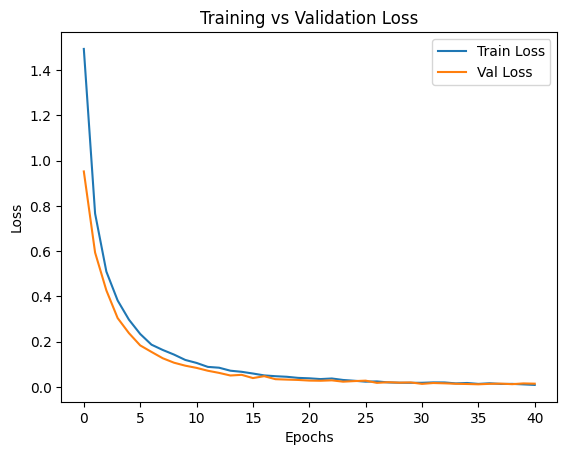

In [23]:
# =========================
# Training Loop with Early Stopping
# =========================
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_head.parameters(), lr=1e-4, weight_decay=1e-4)
EPOCHS = 50
PATIENCE = 5
best_val_loss = float("inf")
wait = 0
best_model_path = "best_model1b.pth"

train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Training
    model_head.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model_head(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    epoch_loss = total_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation
    model_head.eval()
    val_loss = 0.0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model_head(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
    val_loss /= len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Early Stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
        torch.save(model_head.state_dict(), best_model_path)
    else:
        wait += 1
        if wait >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

# Plot losses
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()



Final Test Metrics:
Accuracy  : 0.9983
Precision : 0.9984
Recall    : 0.9983
F1 Score  : 0.9983


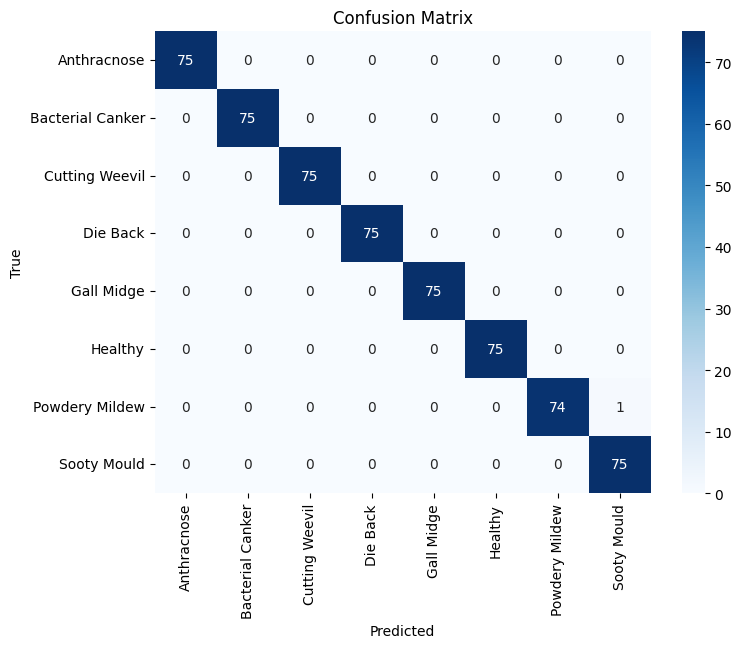

In [24]:
# =========================
# Evaluation
# =========================
model_head.load_state_dict(torch.load(best_model_path))
model_head.eval()

y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        outputs = model_head(xb)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_true.extend(yb.numpy())
        y_pred.extend(preds)

accuracy = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="macro")

print("\nFinal Test Metrics:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

# Optional: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()
